# Phase 6 — Training Transformers

> **Transformer Mastery — Phase Notebook**

## Objective
Turn a Transformer architecture into a reproducible training pipeline. The notebook covers tokenization, batching, train/validation splitting, loss, optimization, gradient clipping, learning-rate scheduling, checkpoints, validation metrics, and training diagnostics.

### Notebook standard
- Reproducible setup
- Concepts → implementation → experiment → interpretation
- Explicit sanity checks
- Visual diagnostics
- Practical takeaways
- Limitations clearly stated

Run from top to bottom in a fresh kernel.

## 1. Setup

In [1]:
import math, random, re, time
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

SEED = 32
random.seed(SEED)
np.random.seed(SEED)

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")

print(f"PyTorch version: {torch.__version__}")

print("All imports done successfully.")

Using device: cpu
PyTorch version: 2.11.0+cpu
All imports done successfully.


## 2. A Tiny Corpus and Tokenizer

We use a deliberately small corpus so every stage of the pipeline remains inspectable. A production system would use a much larger dataset and a subword tokenizer.

In [ ]:
text = (
    "transformers learn relationships between tokens using attention. "
    "attention compares queries and keys and combines values. "
    "training adjusts parameters to reduce prediction error. "
) * 400

# Simple word tokenizer
tokens = re.findall(r"[a-z]+|[.]", text.lower())
counts = Counter(tokens)

special = ["<pad>", "<unk>", "<bos>", "<eos>"]
vocab   = special + [tok for tok, _ in counts.most_common()]

stoi = {tok: i   for i, tok in enumerate(vocab)}
itos = {i: tok   for tok, i in stoi.items()}

encoded = torch.tensor([
    stoi.get(t, stoi["<unk>"]) for t in tokens
], dtype=torch.long)

print(f"Vocabulary size: {len(vocab)}")
print("Token Count    : ",len(encoded))
print("Most common tokens: ", counts.most_common(10))

Vocabulary size: 25
Token Count    :  10000
Most common tokens:  [('.', 1200), ('attention', 800), ('and', 800), ('transformers', 400), ('learn', 400), ('relationships', 400), ('between', 400), ('tokens', 400), ('using', 400), ('compares', 400)]


## 3. Train / Validation Split

In [3]:
split = int(0.9 * len(encoded))

train_ids, val_ids = encoded[:split], encoded[split:]

BLOCK = 16
BATCH = 32

In [4]:
def get_batch(split_name):
    src    = train_ids if split_name == "train" else val_ids
    starts = torch.randint(0, len(src) - BLOCK - 1, (BATCH,))
    x      = torch.stack([src[i:i+BLOCK] for i in starts])
    y      = torch.stack([src[i+1:i+BLOCK+1] for i in starts])   
    return x.to(DEVICE), y.to(DEVICE)

In [5]:
x, y = get_batch("train")

print("Input Shape  :", tuple(x.shape))
print("Target Shape :", tuple(y.shape))
assert x.shape == y.shape == (BATCH, BLOCK), "Input and target shapes do not match expected dimensions."

Input Shape  : (32, 16)
Target Shape : (32, 16)


## 4. Minimal Causal Transformer

In [6]:
class TinyLM(nn.Module):
    def __init__(self, vocab_size, d_model=96, nhead=4, layers=2):
        super().__init__()
        self.token = nn.Embedding(vocab_size, d_model)
        self.pos  = nn.Embedding(BLOCK, d_model)

        layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = 4 * d_model,
            dropout         = 0.1,
            activation      = "gelu",
            batch_first     = True
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=layers)
        self.norm   = nn.LayerNorm(d_model)
        self.head   = nn.Linear(d_model, vocab_size)

    def forward(self, x, targets=None):
        T      = x.size(1)
        pos    = torch.arange(T, device=x.device)
        h      = self.token(x) + self.pos(pos)[None, :, :]
        casual = torch.triu(
            torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal = 1
        )
        h      = self.blocks(h, mask=casual)
        logits = self.head(self.norm(h))

        loss   = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                targets.reshape(-1)
            )
        return logits, loss

model = TinyLM(vocab_size=len(vocab)).to(DEVICE)

print(f"Model has {sum(p.numel() for p in model.parameters())} parameters.")

Model has 230233 parameters.


## 5. Optimization

In [7]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = 3e-4,
    weight_decay = 0.01
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max = 800, eta_min = 3e-5
)

@torch.no_grad()
def evaluate():
    model.eval()
    values = {}
    for name in ["train", "val"]:
        losses = []
        for _ in range(20):
            xb, yb  = get_batch(name)
            _, loss = model(xb, yb)
            losses.append(loss.item())
        values[name] = float(np.mean(losses))
    model.train()
    return values

history  = []
best_val = float('inf')


In [8]:
for step in range(1, 801):
    xb, yb = get_batch("train")
    optimizer.zero_grad(set_to_none=True)

    _, loss = model(xb, yb)
    loss.backward()

    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    if step == 1 or step % 50 == 0:
        m = evaluate()
        lr = optimizer.param_groups[0]["lr"]
        history.append((step, m["train"], m["val"], lr, float(grad_norm)))

        if m["val"] < best_val:
            best_val = m["val"]
            torch.save(
                {"model": model.state_dict(), "step": step, "val_loss": best_val},
                "phase6_best.pt"
            )

        print(
            f"step={step:03d} | train={m['train']:.3f} | "
            f"val={m['val']:.3f} | lr={lr:.6f}"
        )

step=001 | train=3.158 | val=3.161 | lr=0.000300
step=050 | train=0.487 | val=0.486 | lr=0.000297
step=100 | train=0.125 | val=0.127 | lr=0.000290
step=150 | train=0.056 | val=0.054 | lr=0.000277
step=200 | train=0.038 | val=0.042 | lr=0.000260
step=250 | train=0.035 | val=0.033 | lr=0.000240
step=300 | train=0.029 | val=0.029 | lr=0.000217
step=350 | train=0.029 | val=0.028 | lr=0.000191
step=400 | train=0.027 | val=0.026 | lr=0.000165
step=450 | train=0.024 | val=0.024 | lr=0.000139
step=500 | train=0.024 | val=0.025 | lr=0.000113
step=550 | train=0.023 | val=0.023 | lr=0.000090
step=600 | train=0.020 | val=0.023 | lr=0.000070
step=650 | train=0.022 | val=0.022 | lr=0.000053
step=700 | train=0.022 | val=0.022 | lr=0.000040
step=750 | train=0.021 | val=0.022 | lr=0.000033
step=800 | train=0.022 | val=0.022 | lr=0.000030


## 6. Training Diagnostics

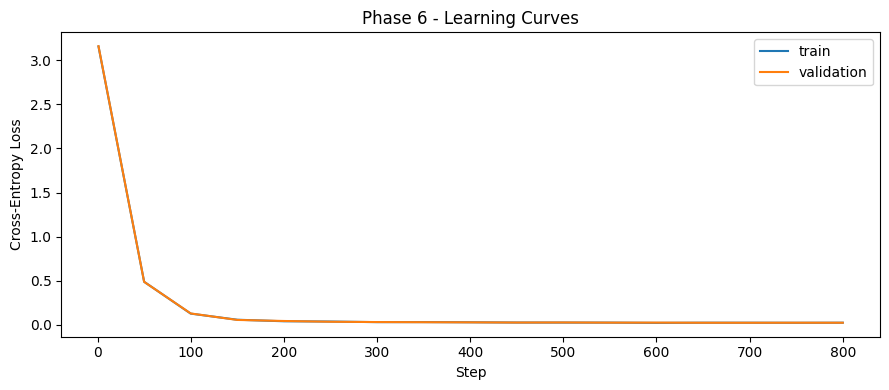

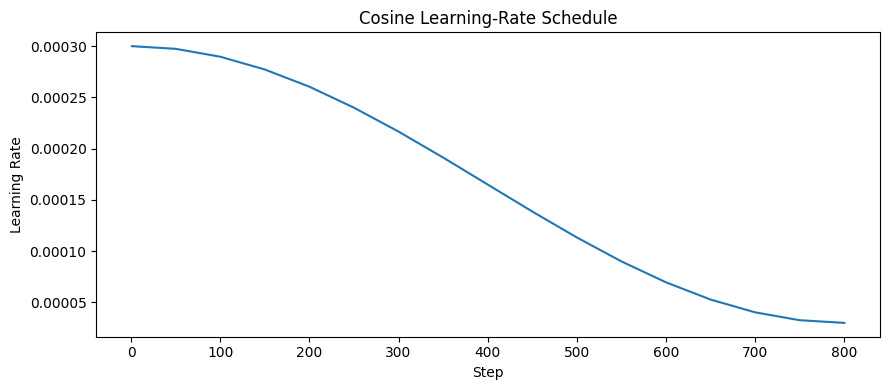

In [9]:
h = np.array(history)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(h[:,0], h[:,1], label="train")
ax.plot(h[:,0], h[:,2], label="validation")
ax.set_xlabel("Step")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Phase 6 - Learning Curves")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(h[:,0], h[:,3], label="learning rate")
ax.set_xlabel("Step")
ax.set_ylabel("Learning Rate")
ax.set_title("Cosine Learning-Rate Schedule")
plt.tight_layout()
plt.show()

## 7. Checkpoint Recovery

In [10]:
checkpoint = torch.load("phase6_best.pt", map_location=DEVICE)
model.load_state_dict(checkpoint["model"])
print(f"Loaded model from step {checkpoint['step']} with validation loss {checkpoint['val_loss']:.3f}.")

Loaded model from step 700 with validation loss 0.022.


## Phase 6 - What You Should Understand

A Transformer is not "trained" simply by calling `.fit()`. The important engineering pieces are:

**data → batches → forward pass → loss → backpropagation → gradient control → optimizer → scheduler → validation → checkpoint**

The validation curve is especially important: lower training loss alone does not prove that the model is learning useful generalizable structure.